For this part, this code will model a chemical reaction with fast kinetics using Euler's backward with a Newton-Raphson iteration. C(t), the reactant conentration, is modelled by the equation C'(t) = -k(C-C_eq(t)). Where C_eq(t) is the equilibrium concentration that varies with time and k is the reaction rate. Using c_eq(t) = 1 + 0.1sin(0.1t) and k = 10e4 s**-1, we find that the standard form of the equation is C'(t) = -10e4C + 10e4(1 + 0.1sin(0.1t)).

C is the concentration of the reactant, C_eq(t) is the time varying equillibrium concentration, and k is the reaction rate, which is very large in order to make the equation stiff. A quick reaction rate changes in very little time while the equillibrium equation changes over a long period of time which makes the equation difficult to solve using more conventional methods like eulers forward. 

In practice this system is important because it models both the very quick and transient dynamics of a chemical reaction and the long term dynamics. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import time

# Parameters
k = 1e4
C_eq = lambda t: 1.0 + 0.1*np.sin(0.1*t)

def f(t, C):
    return -k*(C - C_eq(t))

# Forward Euler
def forward_euler(f, C0, t0, tf, h):
    t = np.arange(t0, tf+h, h)
    C = np.zeros_like(t)
    C[0] = C0
    for i in range(1, len(t)):
        C[i] = C[i-1] + h * f(t[i-1], C[i-1])
    return t, C

# Eulers backward w/ Newton Raphson
def backward_euler_newton(f, C0, t0, tf, h, tol=1e-6, maxiter=10):
    # Initial values and make arrays
    t = np.arange(t0, tf+h, h)
    C = np.zeros_like(t)
    C[0] = C0
    iters = []
    
    # Solve through every step
    for i in range(1, len(t)):
        C_prev = C[i-1]
        C_new = C_prev
        t_next = t[i]
        
        # Perform iterations
        for it in range(1, maxiter+1):
            F = C_new - C_prev - h * f(t_next, C_new)
            dF = 1 + h*k
            C_next = C_new - F/dF
            
            # Exit if tolerance is exceeded
            if abs(C_next - C_new) < tol:
                C_new = C_next
                break
            C_new = C_next
            
        # Count number of iterations run
        C[i] = C_new
        iters.append(it)
    return t, C, iters

# Analytical solution
t_ref = np.linspace(0, 50.0, 1001)
C_ref = odeint(lambda C, t: -k*(C - C_eq(t)), 0.0, t_ref, atol=1e-12, rtol=1e-12).flatten()
t_ref2 = np.linspace(0, 0.05, 1001)
C_ref2 = odeint(lambda C, t: -k*(C - C_eq(t)), 0.0, t_ref2, atol=1e-12, rtol=1e-12).flatten()

Our residual function, definfed by g(C_n+1) = C_n+1 - C_n + hk(C_n+1 - C_eq(t_n+1)) = 0. Its derivative is g'(C_n+1) = 1 + hk. The new newton-raphson formula for this is C_new = C_old - (F(C_old)/F'(C_old)). 
The analytic solution after one step therefore is C_n+1 = (C_n + hkC_eq(t_n+1))/(1 + hk)

This code has both the Eulers forward function and Eulers backward using NR iteration function. Eulers backward returns the t values, C values, and iterations run and eulers forward returns just t and C. 

Max stable h (approx): 0.00018420699693267163


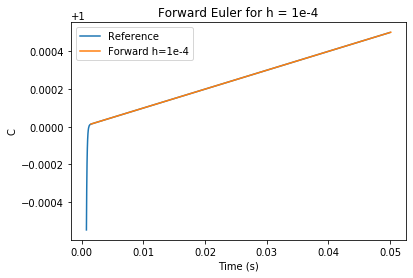

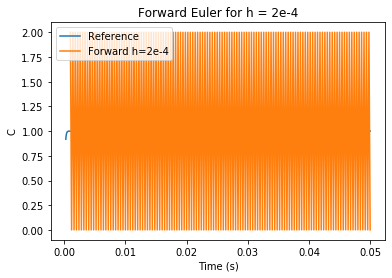

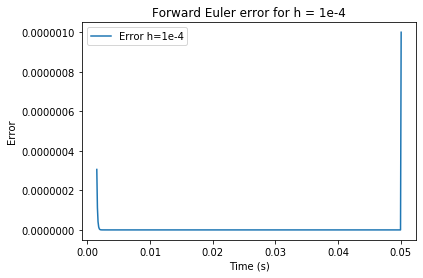

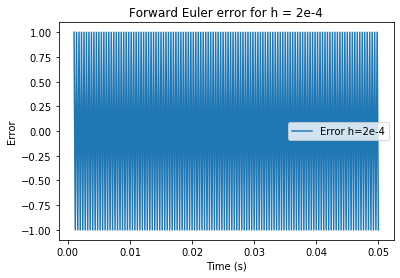

In [2]:
# Stability for Forward Euler for differing step sizes
hs = np.logspace(-5, -3, 50)
stable_h = []
for h in hs:
    t_fe, C_fe = forward_euler(f, 0.0, 0.0, 0.05, h)
    if np.isfinite(C_fe[-1]) and abs(C_fe[-1]) < 10:
        stable_h.append(h)
print("Max stable h (approx):", max(stable_h))
t_ref2 = np.linspace(0, 0.05, 1001)
t_fe1, C_fe1 = forward_euler(f, 0.0, 0.0, 0.05, 1e-4)
t_fe2, C_fe2 = forward_euler(f, 0.0, 0.0, 0.05, 2e-4)

# Plot solutions
plt.figure(figsize=(6,4))
plt.plot(t_ref2[15:], C_ref2[15:], label='Reference')
plt.plot(t_fe1[15:], C_fe1[15:], label='Forward h=1e-4')
plt.xlabel("Time (s)")
plt.ylabel("C")
plt.title("Forward Euler for h = 1e-4")
plt.legend()

plt.figure(figsize=(6,4))
plt.plot(t_ref2[5:], C_ref2[5:], label='Reference')
plt.plot(t_fe2[5:], C_fe2[5:], label='Forward h=2e-4')
plt.xlabel("Time (s)")
plt.ylabel("C")
plt.title("Forward Euler for h = 2e-4")
plt.legend()

# Plot errors
err_fe1 = C_fe1 - np.interp(t_fe1, t_ref2, C_ref2)
err_fe2 = C_fe2 - np.interp(t_fe2, t_ref2, C_ref2)

plt.figure(figsize=(6,4))
plt.plot(t_fe1[15:], err_fe1[15:], label='Error h=1e-4')
plt.xlabel("Time (s)")
plt.ylabel("Error")
plt.title("Forward Euler error for h = 1e-4")
plt.legend()

plt.figure(figsize=(6,4))
plt.plot(t_fe2[5:], err_fe2[5:], label='Error h=2e-4')
plt.xlabel("Time (s)")
plt.ylabel("Error")
plt.title("Forward Euler error for h = 2e-4")
plt.legend()

Here we can calculate the maximum stable step size for Eulers forward for be 0.000184. This would mean it would take 270,000 steps to model the solution of this equation with eulers forward over the time frame of 50 seconds. Any step size larger than this and the solution diverges and the method is no longer useful. 

The stiffness ratio (fastest/slowest time scale = 1000/0.1) is about 10000. This causes implicit methods to be necessary as it is not efficient to solve 270000 steps in order to estimate the solution of this equation. 

For the step size of .0001 the solution converges and has near 0 error. For the solution with step size of .0002 the solution just oscillates with massive error. 

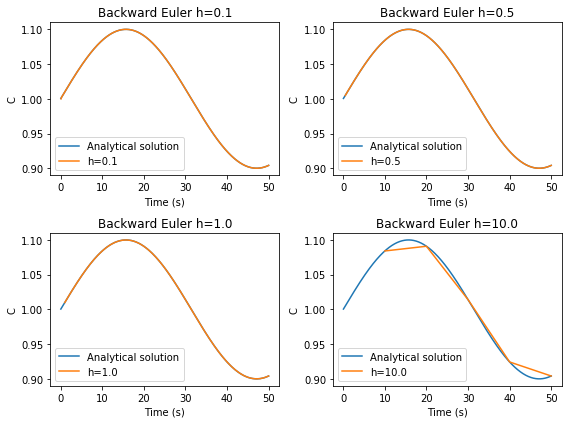

In [3]:
# Plot Eulers Backward for various h 
hs_be = [.1, .5, 1.0, 10.0]
plt.figure(figsize=(8,6))
for i,h in enumerate(hs_be, start=1):
    plt.subplot(2,2,i)
    plt.plot(t_ref[1:], C_ref[1:], label='Analytical solution')
    t_be, C_be, _ = backward_euler_newton(f, 0.0, 0.0, 50.0, h)
    plt.plot(t_be[1:], C_be[1:], label=f"h={h}")
    plt.title(f"Backward Euler h={h}")
    plt.xlabel("Time (s)")
    plt.ylabel("C")
    plt.legend()
plt.tight_layout()

These four figures show Eulers backward for step sizes of 0.1, 0.5, 1.0, and 10.0. We can see here how Eulers backward does not diverge at any step size and thus is stable at all step sizes for a t_max of 50 seconds. At a step size of 1, the solution matches very closely the Eulers backward approximation. At a step size of 10, the only issue is the distance between the points but the approximation still follows the equilibrium behavior of the analytical solution. While Eulers forward is only stable until an h value of .00018, eulers backward maintains stability through the entirity of step sizes. 

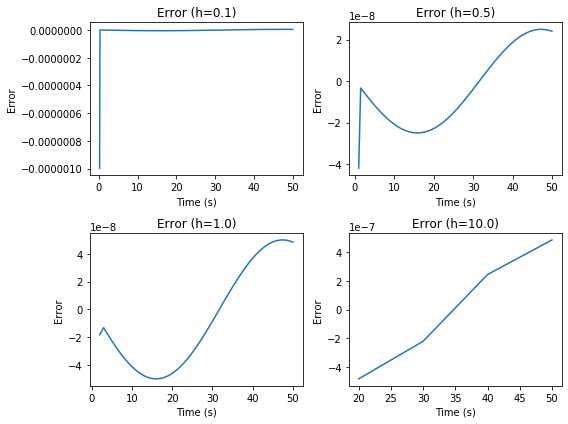

In [4]:
plt.figure(figsize=(8,6))
for i, h in enumerate(hs_be,1):
    t_be, C_be, _ = backward_euler_newton(f, 0.0, 0.0, 50.0, h)
    C_err = C_be - np.interp(t_be, t_ref, C_ref)
    plt.subplot(2,2,i)
    plt.plot(t_be[2:], C_err[2:])
    plt.title(f"Error (h={h})")
    plt.xlabel("Time (s)")
    plt.ylabel("Error")
plt.tight_layout()

These plots show the error of eulers backward which is proportional in magnitude to the equilibrium behavior. The error decreases in magnitude though as the step size decreases, evident when looking at the scale of the graphs y axis. The error is never significant enough to detract from the equilibrium behavior although it might detract from the models accuracy when looking at the transient reaction dynamics. 

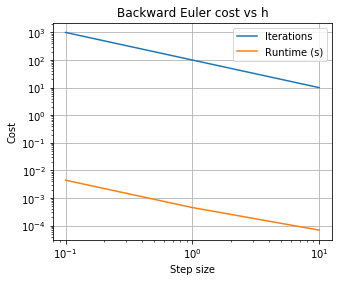

In [5]:
func_iters = []
runtimes = []
for h in hs_be:
    start = time.time()
    t_be, C_be, iters = backward_euler_newton(f, 0.0, 0.0, 50.0, h)
    runtimes.append(time.time() - start)
    func_iters.append(sum(iters))
plt.figure(figsize=(5,4))
plt.loglog(hs_be, func_iters, label='Iterations')
plt.loglog(hs_be, runtimes, label='Runtime (s)')
plt.xlabel("Step size")
plt.ylabel("Cost")
plt.title("Backward Euler cost vs h")
plt.legend()
plt.grid(True)

| Criteria | Eulers Forward | Eulers backward |
|:--------:|:--------:|:--------:|
|  Max step size h (s)   |  .000186   |  >50.0 |
|  Iterations required over t = 50s   |  270000   |  1   |
|  Accuracy for equillibrium behavior  |  high   |  high   |
|  Accuracy for transient behavior   |  high   |  high   |

For Eulers Backwards, the cost decreased linearly with the step size as the iterations decreased linearly. The computational cost for modeling the equillibrium behavior is much higher for eulers forward as many more iterations have to be performed due to its requirement of a low step size. For transient behavior; however, the cost is lower for eulers forward as its still accurate at the small step sizes but its computational cost is lower due to the algorithms simplicity. For higher accuracy, Eulers backwards would be prefered as well as for higher efficiency for longer time durations. For very short time intervals when looking at transient behavior, Eulers forward would have the suppior efficiency. 

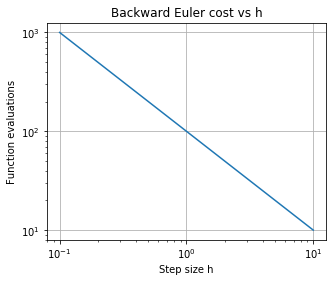

In [6]:
# Performance vs step size 

func_evals = []
for h in hs_be:
    t_be, C_be, iters = backward_euler_newton(f, 0.0, 0.0, 50.0, h)
    func_evals.append(sum(iters))
plt.figure(figsize=(5,4))
plt.loglog(hs_be, func_evals)
plt.xlabel("Step size h")
plt.ylabel("Function evaluations")
plt.title("Backward Euler cost vs h")
plt.grid(True)

In conclusion, for the stiff chemical reaction ODE, Eulers forward fails for moderate step sizes which Eulers backward is stable for all step sizes over the time period. Eulers backward is far more efficient as its able to solve the ODE accurately in far fewer steps than Eulers forward. 

Implicit solvers therefore are better for stiff systems while explicit can be more efficient for non-stiff systems or stiff systems when looking at very small time intervals where iteration number does not become too high. Some challenges encountered were Eulers forward being very unmanageable on the time frame of 50 seconds so a shorter time frame had to be used. Also getting Eulers backward to work for the function was difficult. Some of the early data points in each array were massive outliers so they had to be excluded from the plotted set. 